E-commerce

##Planning

Links

Dataset - https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews$0



Train model

Dummy interface (like amazon)

Model generates useful info on product based off reviews

##Download e-commerce dataset as 'df'

In [74]:
import kagglehub
import pandas
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Womens Clothing E-Commerce Reviews.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nicapotato/womens-ecommerce-clothing-reviews",
  file_path,
  pandas_kwargs={'encoding': 'latin1'}
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_copy = df.copy()
print("First 5 records of the DataFrame:")
display(df_copy.head())


Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.
First 5 records of the DataFrame:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## Data Cleaning

In [75]:
print("Shape:", df.shape)
df.info()


Shape: (23486, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [76]:
missing = df_copy.isna().sum().sort_values(ascending=False)
missing[missing > 0]
missing_div = df_copy[df_copy['Division Name'].isna()].index
missing_dep = df_copy[df_copy['Department Name'].isna()].index
missing_cl = df_copy[df_copy['Class Name'].isna()].index

print("Division == Department:", missing_div.equals(missing_dep))
print("Department == Class:", missing_dep.equals(missing_cl))

df_copy.loc[missing_div, ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']]

Division == Department: True
Department == Class: True


,Clothing ID,Division Name,Department Name,Class Name
9444,72,NaN,NaN,NaN
13767,492,NaN,NaN,NaN
13768,492,NaN,NaN,NaN
13787,492,NaN,NaN,NaN
16216,152,NaN,NaN,NaN
16221,152,NaN,NaN,NaN
16223,152,NaN,NaN,NaN
18626,184,NaN,NaN,NaN
18671,184,NaN,NaN,NaN
20088,772,NaN,NaN,NaN


In [77]:
for clothing_id in df_copy.loc[missing_div, 'Clothing ID'].unique():
    same_item = df_copy[df_copy['Clothing ID'] == clothing_id]
    has_info = same_item['Division Name'].notna().any()
    total = len(same_item)
    filled = same_item['Division Name'].notna().sum()

    print(f"Clothing ID {clothing_id}: {filled}/{total} rows have category info — {'✓ can impute' if has_info else '✗ drop'}")

Clothing ID 72: 0/1 rows have category info — ✗ drop
Clothing ID 492: 0/3 rows have category info — ✗ drop
Clothing ID 152: 0/3 rows have category info — ✗ drop
Clothing ID 184: 0/2 rows have category info — ✗ drop
Clothing ID 772: 0/1 rows have category info — ✗ drop
Clothing ID 665: 0/1 rows have category info — ✗ drop
Clothing ID 136: 0/3 rows have category info — ✗ drop


In [78]:
df_copy = df_copy.drop(index=missing_div)

In [79]:
print(f"shape after drop: {df_copy.shape}")
print(df_copy[['Division Name', 'Department Name', 'Class Name']].isna().sum())

shape after drop: (23472, 11)
Division Name      0
Department Name    0
Class Name         0
dtype: int64


In [80]:
missing[missing > 0]

,0
Title,3810
Review Text,845
Department Name,14
Class Name,14
Division Name,14


In [81]:
df_copy['Title']= df_copy['Title'].fillna('No Title')
df_copy['Review Text'] = df_copy['Review Text'].fillna('No Review')
print(df_copy[['Title', 'Review Text']].isna().sum())


Title          0
Review Text    0
dtype: int64


In [82]:
missing = df_copy.isna().sum().sort_values(ascending=False)
missing[missing>0]

,0


### Removing Low-Volume Products
To ensure statistical significance in our ratings and recommendation logic, we will remove any `Clothing ID` that has fewer than 3 reviews total.

In [100]:
# 1. Count reviews per product
product_counts = df_copy['Clothing ID'].value_counts()

# 2. Identify IDs with < 3 reviews
low_volume_ids = product_counts[product_counts < 3].index
print(f"Number of low-volume products found: {len(low_volume_ids)}")

# 3. Filter the datasets
df_copy = df_copy[~df_copy['Clothing ID'].isin(low_volume_ids)]
df_rating = df_rating[~df_rating['Clothing ID'].isin(low_volume_ids)]

print(f"Remaining records in df_copy: {len(df_copy)}")
print(f"Remaining records in df_rating: {len(df_rating)}")

Number of low-volume products found: 0
Remaining records in df_copy: 22612
Remaining records in df_rating: 22612


##Visualizations



#####Raw Data

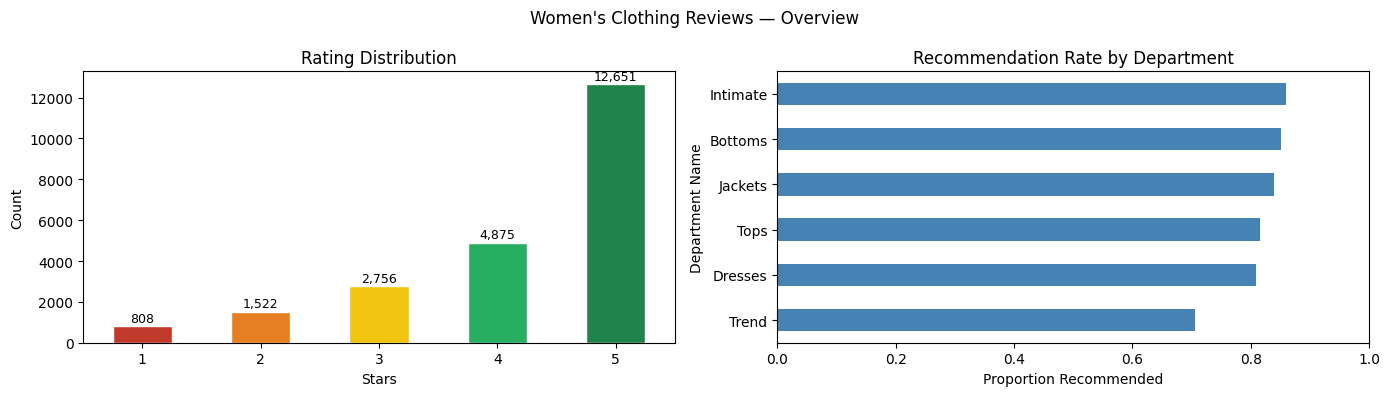

In [84]:
# ── Visualizations: Raw Data ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Women's Clothing Reviews — Overview")

# Plot 1: Rating distribution
df_copy['Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['#c0392b','#e67e22','#f1c40f','#27ae60','#1e8449'],
    edgecolor='white'
)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

# Plot 2: Recommendation rate by department
dept_rec = (df_copy
    .groupby('Department Name')['Recommended IND']
    .mean()
    .sort_values()
)
dept_rec.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Recommendation Rate by Department")
axes[1].set_xlabel("Proportion Recommended")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()













































##Preprocessing


In [85]:
import pandas as pd
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# drop rows with no review text
df_model = df_copy.dropna(subset=['Review Text']).copy()

# drop 3-star rows
df_model = df_model[df_model['Rating'] != 3]

# create binary label
df_model['label'] = (df_model['Rating'] >= 4).astype(int)

print(f"Total rows: {len(df_model):,}")
print(f"Positive (4-5*)): {(df_model['label'] == 1).sum():,}")
print(f"Negative (1-2*): {(df_model['label'] == 0).sum():,}")

# apply preprocessing — takes ~30 seconds
df_model['clean_review'] = df_model['Review Text'].apply(preprocess_text)

# sanity check
print("\nBEFORE:", df_model['Review Text'].iloc[0][:100])
print("AFTER: ", df_model['clean_review'].iloc[0][:100])

Total rows: 19,856
Positive (4-5*)): 17,526
Negative (1-2*): 2,330

BEFORE: Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never
AFTER:  love dress sooo pretty happened find store glad never would ordered online petite bought petite love


#####Word Clouds

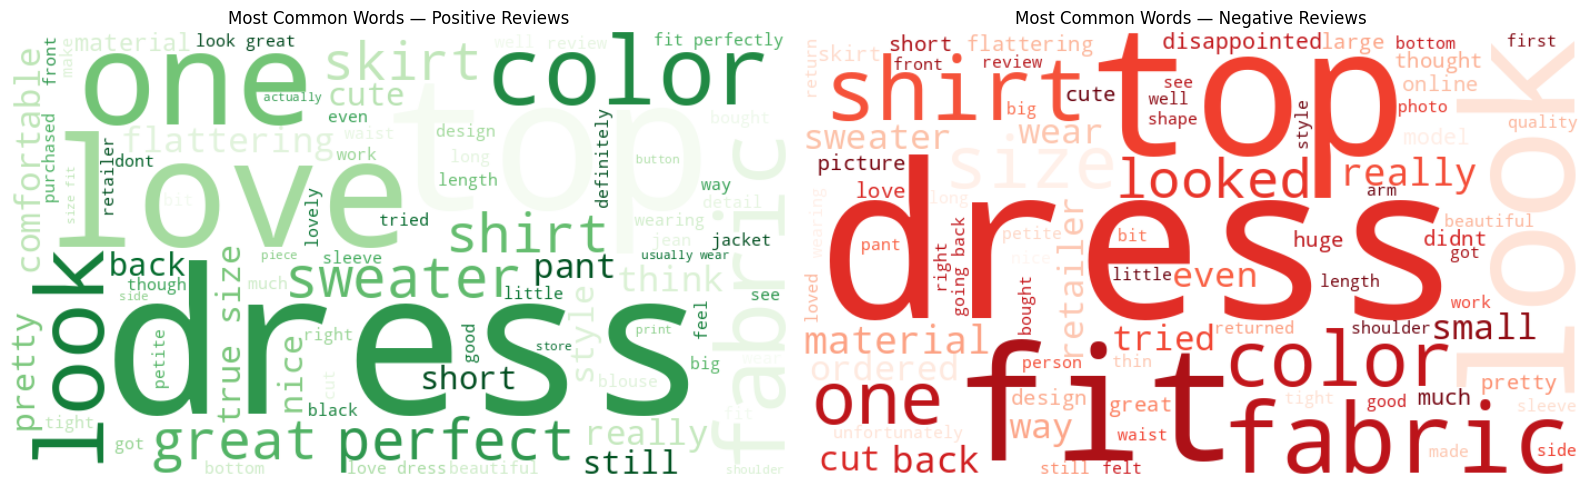

In [86]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df_model[df_model['label'] == 1]['clean_review'])
negative_text = " ".join(df_model[df_model['label'] == 0]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(
    WordCloud(width=700, height=400, colormap='Greens',
              max_words=80, background_color='white')
    .generate(positive_text),
    interpolation='bilinear'
)
axes[0].set_title("Most Common Words — Positive Reviews")
axes[0].axis('off')

axes[1].imshow(
    WordCloud(width=700, height=400, colormap='Reds',
              max_words=80, background_color='white')
    .generate(negative_text),
    interpolation='bilinear'
)
axes[1].set_title("Most Common Words — Negative Reviews")
axes[1].axis('off')

plt.tight_layout()
plt.show()

##Training


In [87]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack

# 1. Prepare Text Features with TF-IDF
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=5000
)

X_text_tfidf = tfidf.fit_transform(df_model['clean_review'])

# 2. Prepare Numerical Features (Age and Recommended IND)
# We reshape them to (n_samples, 1) so they can be stacked
X_num = df_model[['Age', 'Recommended IND']].values

# 3. Combine Features using hstack
X_combined = hstack([X_text_tfidf, X_num])
y = df_model['label']

# 4. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Initialize and fit Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [88]:
# 6. Evaluate the model
y_pred = model.predict(X_test)

print("--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Test the model with a custom sample
def predict_sentiment(review_text, age, recommended_ind):
    clean = preprocess_text(review_text)
    text_vec = tfidf.transform([clean])
    num_vec = np.array([[age, recommended_ind]])
    combined_vec = hstack([text_vec, num_vec])

    prediction = model.predict(combined_vec)[0]
    probability = model.predict_proba(combined_vec)[0]

    sentiment = "Positive (4-5*)" if prediction == 1 else "Negative (1-2*)"
    print(f"Review: {review_text}")
    print(f"Predicted: {sentiment} (Confidence: {probability[prediction]:.2%})")

print("\n--- Sample Tests ---")
predict_sentiment("This dress is absolutely beautiful and fits perfectly!", 35, 1)
predict_sentiment("Terrible quality, the fabric felt cheap and it fell apart after one wash.", 28, 0)

--- Model Evaluation ---
Accuracy Score: 0.9844

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       466
           1       0.99      0.99      0.99      3506

    accuracy                           0.98      3972
   macro avg       0.95      0.97      0.96      3972
weighted avg       0.98      0.98      0.98      3972


--- Sample Tests ---
Review: This dress is absolutely beautiful and fits perfectly!
Predicted: Positive (4-5*) (Confidence: 99.73%)
Review: Terrible quality, the fabric felt cheap and it fell apart after one wash.
Predicted: Negative (1-2*) (Confidence: 96.89%)


### Multi-class Rating Prediction
This model predicts the exact rating (1, 2, 3, 4, or 5) using the full dataset.

In [89]:
# 1. Prepare data including all ratings
df_rating = df_copy.dropna(subset=['Review Text']).copy()
df_rating['clean_review'] = df_rating['Review Text'].apply(preprocess_text)

# 2. Feature Engineering
tfidf_rating = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
X_text_rating = tfidf_rating.fit_transform(df_rating['clean_review'])
X_num_rating = df_rating[['Age', 'Recommended IND']].values
X_combined_rating = hstack([X_text_rating, X_num_rating])

y_rating = df_rating['Rating']

# 3. Train/Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_combined_rating, y_rating, test_size=0.20, random_state=42, stratify=y_rating
)

# 4. Multi-class Logistic Regression
rating_model = LogisticRegression(max_iter=2000, multi_class='multinomial')
rating_model.fit(X_train_r, y_train_r)

# 5. Evaluation
y_pred_r = rating_model.predict(X_test_r)
print("--- Multi-class Rating Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_r, y_pred_r):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_r, y_pred_r))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Multi-class Rating Evaluation ---
Accuracy: 0.6666

Classification Report:
              precision    recall  f1-score   support

           1       0.49      0.20      0.29       162
           2       0.37      0.37      0.37       304
           3       0.47      0.39      0.43       551
           4       0.50      0.31      0.38       975
           5       0.76      0.93      0.84      2531

    accuracy                           0.67      4523
   macro avg       0.52      0.44      0.46      4523
weighted avg       0.63      0.67      0.64      4523



In [90]:
def predict_exact_rating(review_text, age, recommended_ind):
    clean = preprocess_text(review_text)
    text_vec = tfidf_rating.transform([clean])
    num_vec = np.array([[age, recommended_ind]])
    combined_vec = hstack([text_vec, num_vec])

    prediction = rating_model.predict(combined_vec)[0]
    print(f"Review: {review_text}")
    print(f"Predicted Rating: {prediction} Stars")

print("--- Multi-class Sample Tests ---")
predict_exact_rating("It's okay, not great but not terrible either.", 40, 0)
predict_exact_rating("The best purchase I have ever made!", 25, 1)

--- Multi-class Sample Tests ---
Review: It's okay, not great but not terrible either.
Predicted Rating: 1 Stars
Review: The best purchase I have ever made!
Predicted Rating: 5 Stars


### Continuous Rating Prediction (Regression)
This model treats the Rating as a continuous floating-point value between 1.0 and 5.0.

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare Target Variable as Float
y_reg = df_rating['Rating'].astype(float).values

# 2. Train/Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_combined_rating, y_reg, test_size=0.20, random_state=42
)

# 3. Initialize and fit Linear Regression
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# 4. Evaluation
y_pred_reg = reg_model.predict(X_test_reg)

# Clip predictions to stay within the 1-5 range for physical realism
y_pred_reg_clipped = np.clip(y_pred_reg, 1.0, 5.0)

mse = mean_squared_error(y_test_reg, y_pred_reg_clipped)
r2 = r2_score(y_test_reg, y_pred_reg_clipped)

print("--- Regression Model Evaluation ---")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

--- Regression Model Evaluation ---
Mean Squared Error: 0.4257
R-squared Score: 0.6569


### Exporting the Model for Production
We need to save both the `tfidf_rating` object (to process new text) and the `reg_model` object (to make predictions).

In [104]:
import joblib

# Save the vectorizer
joblib.dump(tfidf_rating, 'tfidf_vectorizer.pkl')

# Save the regression model
joblib.dump(reg_model, 'worthiness_regression_model.pkl')

print("Models saved successfully! You can find 'tfidf_vectorizer.pkl' and 'worthiness_regression_model.pkl' in the file sidebar.")

Models saved successfully! You can find 'tfidf_vectorizer.pkl' and 'worthiness_regression_model.pkl' in the file sidebar.


#### Example: How to load in your app
```python
# In your application code:
# import joblib
# model = joblib.load('worthiness_regression_model.pkl')
# vectorizer = joblib.load('tfidf_vectorizer.pkl')
```

In [92]:
def predict_continuous_rating(review_text, age, recommended_ind):
    clean = preprocess_text(review_text)
    text_vec = tfidf_rating.transform([clean])
    num_vec = np.array([[age, recommended_ind]])
    combined_vec = hstack([text_vec, num_vec])

    prediction = reg_model.predict(combined_vec)[0]
    prediction = np.clip(prediction, 1.0, 5.0)

    print(f"Review: {review_text}")
    print(f"Predicted Continuous Rating: {prediction:.2f} Stars")

print("--- Regression Sample Tests ---")
predict_continuous_rating("It's okay, not great but not terrible either.", 40, 0)
predict_continuous_rating("The best purchase I have ever made!", 25, 1)
predict_continuous_rating("I wanted to love this, but the fit was slightly off.", 30, 0)

--- Regression Sample Tests ---
Review: It's okay, not great but not terrible either.
Predicted Continuous Rating: 1.49 Stars
Review: The best purchase I have ever made!
Predicted Continuous Rating: 4.54 Stars
Review: I wanted to love this, but the fit was slightly off.
Predicted Continuous Rating: 2.41 Stars


### Age-Based Neighborhood Prediction (Barcode Scanner Model)
This logic predicts a rating by aggregating context from users within a similar age range (N=20%).

In [93]:
def predict_for_barcode_scanner(user_age, n_percent=20):
    # 1. Define the age range
    age_margin = user_age * (n_percent / 100)
    min_age = user_age - age_margin
    max_age = user_age + age_margin

    # 2. Filter reviews within that age range
    neighbor_reviews = df_rating[(df_rating['Age'] >= min_age) & (df_rating['Age'] <= max_age)]

    if neighbor_reviews.empty:
        return f"No reviews found for age range {min_age:.1f} - {max_age:.1f}"

    # 3. Aggregate data from neighbors
    # Concatenate all clean reviews in this age bracket
    combined_text = " ".join(neighbor_reviews['clean_review'].astype(str))
    # Average recommendation status
    avg_rec = neighbor_reviews['Recommended IND'].mean()

    # 4. Vectorize and Predict using the regression model
    text_vec = tfidf_rating.transform([combined_text])
    num_vec = np.array([[user_age, avg_rec]])
    combined_vec = hstack([text_vec, num_vec])

    pred_rating = reg_model.predict(combined_vec)[0]
    pred_rating = np.clip(pred_rating, 1.0, 5.0)

    print(f"--- Barcode Scanner Prediction for Age {user_age} ---")
    print(f"Age Window: {min_age:.1f} to {max_age:.1f}")
    print(f"Reviews analyzed in this bracket: {len(neighbor_reviews)}")
    print(f"Average Recommendation Rate in bracket: {avg_rec:.2%}")
    print(f"Predicted Rating for this demographic: {pred_rating:.2f} Stars")

# Test for a few different ages
predict_for_barcode_scanner(user_age=25)
predict_for_barcode_scanner(user_age=55)

--- Barcode Scanner Prediction for Age 25 ---
Age Window: 20.0 to 30.0
Reviews analyzed in this bracket: 3122
Average Recommendation Rate in bracket: 81.13%
Predicted Rating for this demographic: 5.00 Stars
--- Barcode Scanner Prediction for Age 55 ---
Age Window: 44.0 to 66.0
Reviews analyzed in this bracket: 9091
Average Recommendation Rate in bracket: 83.31%
Predicted Rating for this demographic: 5.00 Stars


### Final Recommendation Logic
This combines the regression model's nuance with demographic agreement to give a definitive 'Worth Buying' verdict.

In [94]:
def evaluate_purchase_worthiness(user_age, clothing_id, threshold_rating=4.0, threshold_rec=0.80):
    # 1. Filter by Clothing ID first
    item_reviews = df_rating[df_rating['Clothing ID'] == clothing_id]

    if item_reviews.empty:
        print(f"No data found for Clothing ID {clothing_id}.")
        return

    # 2. Define the age neighborhood (20%)
    age_margin = user_age * 0.20
    neighbors = item_reviews[(item_reviews['Age'] >= user_age - age_margin) & (item_reviews['Age'] <= user_age + age_margin)]

    if neighbors.empty:
        print(f"No reviews for Clothing ID {clothing_id} within age range of {user_age}.")
        # Fallback: analyze the item across all ages if specific demographic is missing
        neighbors = item_reviews
        print("Falling back to all-age data for this item.")

    # 3. Aggregate demographic traits for this specific item
    combined_text = " ".join(neighbors['clean_review'].astype(str))
    avg_rec = neighbors['Recommended IND'].mean()

    # 4. Predict using Regression
    text_vec = tfidf_rating.transform([combined_text])
    num_vec = np.array([[user_age, avg_rec]])
    combined_vec = hstack([text_vec, num_vec])
    pred_rating = np.clip(reg_model.predict(combined_vec)[0], 1.0, 5.0)

    # Decision Logic
    is_worth_it = (pred_rating >= threshold_rating) and (avg_rec >= threshold_rec)

    print(f"--- Analysis for Product {clothing_id} (User Age: {user_age}) ---")
    print(f"Predicted Personal Rating: {pred_rating:.2f} / 5.0")
    print(f"Demographic Recommendation Rate: {avg_rec:.1%}")
    print(f"VERDICT: {'✅ WORTH BUYING' if is_worth_it else '❌ NOT RECOMMENDED'}")
    print("-" * 45)

# Let's test it on a specific item (e.g., ID 1077) for a 45-year-old
evaluate_purchase_worthiness(user_age=45, clothing_id=1077)
# And another item (e.g., ID 847) for a 21-year-old
evaluate_purchase_worthiness(user_age=21, clothing_id=847)

--- Analysis for Product 1077 (User Age: 45) ---
Predicted Personal Rating: 4.82 / 5.0
Demographic Recommendation Rate: 75.4%
VERDICT: ❌ NOT RECOMMENDED
---------------------------------------------
No reviews for Clothing ID 847 within age range of 21.
Falling back to all-age data for this item.
--- Analysis for Product 847 (User Age: 21) ---
Predicted Personal Rating: 3.66 / 5.0
Demographic Recommendation Rate: 75.0%
VERDICT: ❌ NOT RECOMMENDED
---------------------------------------------


### Multi-Signal Worthiness Score
This advanced metric aggregates three signals: Model Prediction, Demographic Recommendation Rate, and Social Proof (Positive Feedback Count).

In [95]:
def calculate_worthiness_score(user_age, clothing_id, age_range=15):
    # 1. Filter data
    item_reviews = df_rating[df_rating['Clothing ID'] == clothing_id]
    if item_reviews.empty:
        print(f"No data for Clothing ID {clothing_id}")
        return

    # Strategy: Cascading Fallback
    # Tier 1: Original requested range
    neighbors = item_reviews[(item_reviews['Age'] >= user_age - age_range) & (item_reviews['Age'] <= user_age + age_range)]
    demo_context = f"Age {user_age} Neighborhood (+/- {age_range} years)"

    # Tier 2: If Tier 1 is too small, double the window (30 years total)
    if len(neighbors) < 2:
        wider_range = age_range * 2
        neighbors = item_reviews[(item_reviews['Age'] >= user_age - wider_range) & (item_reviews['Age'] <= user_age + wider_range)]
        demo_context = f"Extended Neighborhood (+/- {wider_range} years)"

    # Tier 3: Final Fallback to Global
    if len(neighbors) < 2:
        neighbors = item_reviews
        demo_context = "Global (Item Average)"

    # --- Calculation Logic ---
    combined_text = " ".join(neighbors['clean_review'].astype(str))
    avg_rec = neighbors['Recommended IND'].mean()
    text_vec = tfidf_rating.transform([combined_text])
    num_vec = np.array([[user_age, avg_rec]])
    pred_rating = np.clip(reg_model.predict(hstack([text_vec, num_vec]))[0], 1.0, 5.0)

    signal_prediction = ((pred_rating - 1) / 4) * 100
    signal_community = avg_rec * 100
    avg_feedback = neighbors['Positive Feedback Count'].mean()
    signal_social = np.clip((np.log1p(avg_feedback) / np.log1p(20)) * 100, 0, 100)

    final_score = (signal_prediction * 0.5) + (signal_community * 0.3) + (signal_social * 0.2)

    print(f"--- Multi-Signal Report: Item {clothing_id} ---")
    print(f"Context Strategy: {demo_context}")
    print(f"Sample Size: {len(neighbors)} reviews used")
    print(f"1. Personal Match: {signal_prediction:.1f}/100")
    print(f"2. Community Trust: {signal_community:.1f}/100")
    print(f"3. Social Proof: {signal_social:.1f}/100")
    print(f"\nWORTHINESS SCORE: {final_score:.2f} / 100")
    print("-" * 40)

# Re-test item 1059 with the new cascading logic
calculate_worthiness_score(35, 1059, age_range=15)

--- Multi-Signal Report: Item 1059 ---
Context Strategy: Age 35 Neighborhood (+/- 15 years)
Sample Size: 199 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 82.9/100
3. Social Proof: 38.1/100

WORTHINESS SCORE: 82.49 / 100
----------------------------------------


In [96]:
print("Comparing a high-volume popular item vs a low-volume risky item for a 30-year-old:\n")
# Item 1078 (Dresses - usually high volume)
calculate_worthiness_score(30, 1078)
# Item 862 (Tops - different demographic profile)
calculate_worthiness_score(30, 862)

Comparing a high-volume popular item vs a low-volume risky item for a 30-year-old:

--- Multi-Signal Report: Item 1078 ---
Context Strategy: Age 30 Neighborhood (+/- 15 years)
Sample Size: 648 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 81.6/100
3. Social Proof: 42.2/100

WORTHINESS SCORE: 82.92 / 100
----------------------------------------
--- Multi-Signal Report: Item 862 ---
Context Strategy: Age 30 Neighborhood (+/- 15 years)
Sample Size: 482 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 83.0/100
3. Social Proof: 40.6/100

WORTHINESS SCORE: 83.02 / 100
----------------------------------------


In [103]:
import random

# 1. Get 10 random unique clothing IDs from the dataset
random_product_ids = random.sample(list(df_rating['Clothing ID'].unique()), 10)

print(f"--- Batch Analysis for 10 Random Products (Target Age: 40) ---\n")

# 2. Iterate and evaluate
for prod_id in random_product_ids:
    calculate_worthiness_score(user_age=40, clothing_id=prod_id)

--- Batch Analysis for 10 Random Products (Target Age: 40) ---

--- Multi-Signal Report: Item 705 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 3 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 100.0/100
3. Social Proof: 22.8/100

WORTHINESS SCORE: 84.54 / 100
----------------------------------------
--- Multi-Signal Report: Item 177 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 2 reviews used
1. Personal Match: 87.3/100
2. Community Trust: 100.0/100
3. Social Proof: 22.8/100

WORTHINESS SCORE: 78.20 / 100
----------------------------------------
--- Multi-Signal Report: Item 954 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 7 reviews used
1. Personal Match: 92.6/100
2. Community Trust: 85.7/100
3. Social Proof: 34.5/100

WORTHINESS SCORE: 78.89 / 100
----------------------------------------
--- Multi-Signal Report: Item 583 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 3 revie

### Test Your Own Inputs
Adjust the variables below to see how a specific product performs for a specific age demographic.

In [102]:
# @title Product Worthiness Calculator
target_age = 40 # @param {type:"integer"}
product_id = 1078 # @param {type:"integer"}

calculate_worthiness_score(user_age=target_age, clothing_id=product_id)

--- Multi-Signal Report: Item 1078 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 829 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 81.3/100
3. Social Proof: 41.8/100

WORTHINESS SCORE: 82.76 / 100
----------------------------------------


In [99]:
calculate_worthiness_score(user_age=35, clothing_id=1059)

--- Multi-Signal Report: Item 1059 ---
Context Strategy: Age 35 Neighborhood (+/- 15 years)
Sample Size: 199 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 82.9/100
3. Social Proof: 38.1/100

WORTHINESS SCORE: 82.49 / 100
----------------------------------------
